# 07_RNN_SensorEval

노이즈 이미지 실험 대상 4개 trial(Val1, Val2, Val8, Val9)의
원본 센서 데이터에 대해 RNN 센서 모델 이상탐지 성능 평가.

- 모델: `best_rnn.pt` (4채널: V, I, TS, WFR)
- 데이터: `original_INC_202501/Val{1,2,8,9}_*/` 센서 CSV
- 전처리: trial 내부 z-score → 글로벌 StandardScaler (Train 기준 fit)
- 윈도우: size=30, step=10 (3초 / 1초 슬라이드)
- 지표: Accuracy / Weighted F1 / Macro F1 / ROC-AUC / PR-AUC

In [1]:
from pathlib import Path
import torch

BASE_DIR   = Path.home() / 'Desktop' / 'ai1' / 'noise_target'
SENSOR_DIR = BASE_DIR / 'original_INC_202501'
RNN_PATH   = BASE_DIR / 'best_rnn.pt'

FEATURES    = ['Avg Voltage', 'Avg Current']
WINDOW_SIZE = 30
STEP_SIZE   = 10
THRESHOLD   = 0.5
RANDOM_SEED = 42

# 평가 대상 trial (노이즈 이미지 실험과 동일)
TARGET_TRIALS = {'Val1', 'Val2', 'Val8', 'Val9'}

# 라벨 (label_mapping 기반)
TARGET_LABELS = {'Val1': 1, 'Val2': 1, 'Val8': 0, 'Val9': 0}

# 글로벌 스케일러 fit 대상: Test1~43 (44,45 제외)
NORMAL_TEST_IDS   = {1,2,3,4,5,7,8,9,10,11,12,28,29,30,44}
ABNORMAL_TEST_IDS = {6,31,45} | set(range(32,44))
VAL_TRIAL_IDS     = {44, 45}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'평가 대상: {TARGET_TRIALS}')
print(f'라벨: {TARGET_LABELS}')

Device: cuda
평가 대상: {'Val2', 'Val1', 'Val9', 'Val8'}
라벨: {'Val1': 1, 'Val2': 1, 'Val8': 0, 'Val9': 0}


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('임포트 완료')

임포트 완료


In [3]:
# RNN 모델 정의 및 로드
class RNNAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.rnn1  = nn.RNN(n_features, hidden1, batch_first=True, nonlinearity='tanh')
        self.drop1 = nn.Dropout(dropout)
        self.rnn2  = nn.RNN(hidden1, hidden2, batch_first=True, nonlinearity='tanh')
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.rnn1(x);  out = self.drop1(out)
        out, _ = self.rnn2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


rnn_model = RNNAnomalyDetector(n_features=4, hidden1=32, hidden2=16, dropout=0.5).to(DEVICE)
rnn_model.load_state_dict(
    torch.load(str(RNN_PATH), map_location=DEVICE, weights_only=True))
rnn_model.eval()
print(f'RNN 로드 완료: {RNN_PATH.name}')

RNN 로드 완료: best_rnn.pt


In [4]:
# 전체 센서 데이터 로드 + trial z-score
def parse_folder(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def parse_meta(name):
    m = re.search(r'_(\d+)TS_(\d+)WFR', name, re.IGNORECASE)
    if not m: return None, None
    return float(m.group(1)), float(m.group(2))

all_data   = {}   # {short: (arr_4ch, label, split)}
train_arrs = []   # 글로벌 스케일러 fit용

for d in sorted(SENSOR_DIR.iterdir()):
    if not d.is_dir(): continue
    ptype, idx = parse_folder(d.name)
    if ptype is None: continue
    ts, wfr = parse_meta(d.name)
    if ts is None: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue

    raw = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mn, sd = raw.mean(0), raw.std(0); sd[sd < 1e-8] = 1e-8
    vi = (raw - mn) / sd
    arr = np.hstack([vi,
                     np.full((len(vi), 1), ts),
                     np.full((len(vi), 1), wfr)]).astype(np.float32)

    short = f'{ptype}{idx}'
    if ptype == 'Test':
        if idx in NORMAL_TEST_IDS:   label = 0
        elif idx in ABNORMAL_TEST_IDS: label = 1
        else: continue
        split = 'val' if idx in VAL_TRIAL_IDS else 'train'
    else:  # Val
        label = TARGET_LABELS.get(short)
        if label is None: continue
        split = 'target'

    all_data[short] = (arr, label, split)
    if split == 'train':
        train_arrs.append(arr)

print(f'로드된 trial: {len(all_data)}개')
print(f'  train: {sum(1 for _,_,s in all_data.values() if s=="train")}  '
      f'val: {sum(1 for _,_,s in all_data.values() if s=="val")}  '
      f'target: {sum(1 for _,_,s in all_data.values() if s=="target")}')

로드된 trial: 18개
  train: 12  val: 2  target: 4


In [5]:
# 글로벌 StandardScaler fit (train 기준)
scaler = StandardScaler()
scaler.fit(np.vstack(train_arrs).reshape(-1, 4))

# 스케일 적용
scaled_data = {}
for short, (arr, label, split) in all_data.items():
    scaled_data[short] = (scaler.transform(arr).astype(np.float32), label, split)

print('글로벌 StandardScaler fit 완료 (Train 기준)')
print(f'  피처 mean: {scaler.mean_.round(3)}')
print(f'  피처 std : {scaler.scale_.round(3)}')

글로벌 StandardScaler fit 완료 (Train 기준)
  피처 mean: [ -0.     -0.     24.142 176.102]
  피처 std : [ 1.     1.     5.653 13.882]


In [6]:
# 윈도우 생성 + RNN 추론
def make_windows(arr, ws, ss):
    return np.stack([arr[s:s+ws] for s in range(0, len(arr)-ws+1, ss)])


@torch.no_grad()
def infer_windows(windows):
    """(N, 30, 4) → (N,) 이상 확률"""
    x = torch.from_numpy(windows).to(DEVICE)
    return rnn_model(x).cpu().numpy()


# 대상 4개 trial에 대해 윈도우 추론
target_results = []
for short, (arr, label, split) in scaled_data.items():
    if split != 'target': continue
    wins  = make_windows(arr, WINDOW_SIZE, STEP_SIZE)   # (N, 30, 4)
    probs = infer_windows(wins)                          # (N,)
    preds = (probs >= THRESHOLD).astype(int)
    time_secs = np.array([
        (s + WINDOW_SIZE - 1) / 10.0
        for s in range(0, len(arr)-WINDOW_SIZE+1, STEP_SIZE)
    ])  # 윈도우 끝 시점 (초)
    for i in range(len(wins)):
        target_results.append({
            'trial':   short,
            'label':   label,
            'time_s':  round(time_secs[i], 2),
            'prob':    round(float(probs[i]), 4),
            'pred':    int(preds[i]),
            'correct': int(preds[i] == label),
        })

df_all = pd.DataFrame(target_results)
print('추론 완료')
for t in sorted(df_all['trial'].unique()):
    sub = df_all[df_all['trial']==t]
    print(f'  {t}  windows={len(sub)}  label={sub["label"].iloc[0]}  '
          f'acc={sub["correct"].mean():.3f}  prob_mean={sub["prob"].mean():.3f}')

추론 완료
  Val1  windows=24  label=1  acc=0.000  prob_mean=0.377
  Val2  windows=31  label=1  acc=1.000  prob_mean=0.971
  Val8  windows=32  label=0  acc=1.000  prob_mean=0.425
  Val9  windows=30  label=0  acc=0.867  prob_mean=0.508


In [7]:
# 전체 평가 (4개 trial 합산)
y_true = df_all['label'].values
y_pred = df_all['pred'].values
y_prob = df_all['prob'].values

print('=' * 55)
print(f'  전체 (Val1+2+8+9)  n={len(df_all)}  '
      f'정상={(y_true==0).sum()}  이상={(y_true==1).sum()}')
print('=' * 55)
print(classification_report(y_true, y_pred,
                            labels=[0, 1],
                            target_names=['Normal(0)', 'Abnormal(1)'],
                            zero_division=0))
roc = roc_auc_score(y_true, y_prob)
pr  = average_precision_score(y_true, y_prob)
wf1 = f1_score(y_true, y_pred, labels=[0,1], average='weighted', zero_division=0)
mf1 = f1_score(y_true, y_pred, labels=[0,1], average='macro',    zero_division=0)
acc = (y_true == y_pred).mean()
print(f'Accuracy   : {acc:.4f}')
print(f'Weighted F1: {wf1:.4f}')
print(f'Macro F1   : {mf1:.4f}')
print(f'ROC-AUC    : {roc:.4f}')
print(f'PR-AUC     : {pr:.4f}')

# trial별 요약
print('\n--- trial별 요약 ---')
trial_summary = []
for t in sorted(df_all['trial'].unique()):
    sub = df_all[df_all['trial']==t]
    yt  = sub['label'].values
    yp  = sub['pred'].values
    ypr = sub['prob'].values
    twf1 = f1_score(yt, yp, labels=[0,1], average='weighted', zero_division=0)
    tmf1 = f1_score(yt, yp, labels=[0,1], average='macro',    zero_division=0)
    trial_summary.append({
        'trial': t, 'label': int(yt[0]), 'n': len(sub),
        'accuracy':    round((yt==yp).mean(), 4),
        'weighted_f1': round(twf1, 4),
        'macro_f1':    round(tmf1, 4),
        'prob_mean':   round(ypr.mean(), 4),
    })
    print(f'  {t}  label={int(yt[0])}  n={len(sub)}  '
          f'acc={round((yt==yp).mean(),3)}  W-F1={round(twf1,3)}  '
          f'Macro-F1={round(tmf1,3)}  prob={round(ypr.mean(),3)}')

  전체 (Val1+2+8+9)  n=117  정상=62  이상=55
              precision    recall  f1-score   support

   Normal(0)       0.71      0.94      0.81        62
 Abnormal(1)       0.89      0.56      0.69        55

    accuracy                           0.76       117
   macro avg       0.80      0.75      0.75       117
weighted avg       0.79      0.76      0.75       117

Accuracy   : 0.7607
Weighted F1: 0.7507
Macro F1   : 0.7472
ROC-AUC    : 0.5636
PR-AUC     : 0.7428

--- trial별 요약 ---
  Val1  label=1  n=24  acc=0.0  W-F1=0.0  Macro-F1=0.0  prob=0.377
  Val2  label=1  n=31  acc=1.0  W-F1=1.0  Macro-F1=0.5  prob=0.971
  Val8  label=0  n=32  acc=1.0  W-F1=1.0  Macro-F1=0.5  prob=0.425
  Val9  label=0  n=30  acc=0.867  W-F1=0.929  Macro-F1=0.464  prob=0.508


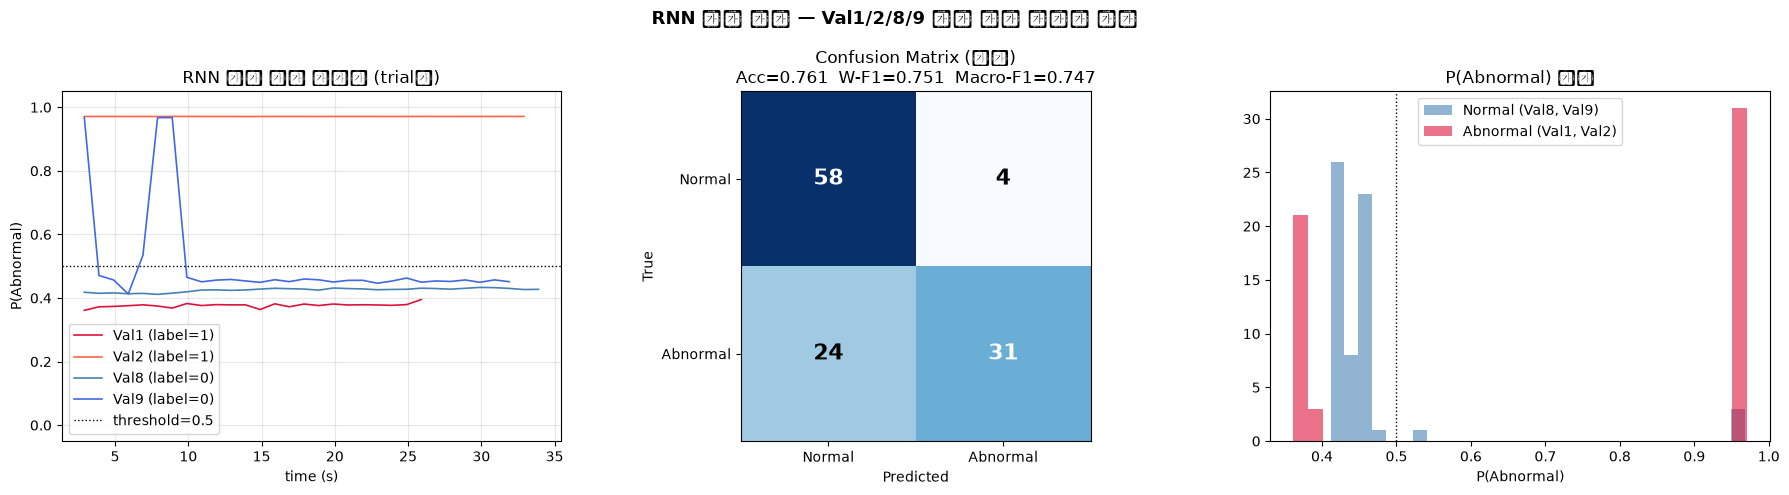

In [8]:
# 시각화
trials  = sorted(df_all['trial'].unique())
n_trial = len(trials)
colors  = {'Val1': 'crimson', 'Val2': 'tomato',
            'Val8': 'steelblue', 'Val9': 'royalblue'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 확률 시계열 ────────────────────────────────────────────────────
ax = axes[0]
for t in trials:
    sub = df_all[df_all['trial']==t].sort_values('time_s')
    lbl = TARGET_LABELS[t]
    ax.plot(sub['time_s'], sub['prob'], color=colors.get(t, 'gray'),
            label=f'{t} (label={lbl})', linewidth=1.2)
ax.axhline(THRESHOLD, color='k', linestyle=':', lw=1, label='threshold=0.5')
ax.set_title('RNN 이상 확률 시계열 (trial별)')
ax.set_xlabel('time (s)'); ax.set_ylabel('P(Abnormal)')
ax.set_ylim(-0.05, 1.05); ax.legend(); ax.grid(alpha=0.3)

# ── 혼동행렬 (전체) ────────────────────────────────────────────────
ax = axes[1]
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
ax.imshow(cm, cmap='Blues')
ax.set(xticks=[0,1], yticks=[0,1],
       xticklabels=['Normal','Abnormal'],
       yticklabels=['Normal','Abnormal'],
       xlabel='Predicted', ylabel='True',
       title=f'Confusion Matrix (전체)\nAcc={acc:.3f}  W-F1={wf1:.3f}  Macro-F1={mf1:.3f}')
th = cm.max() / 2
for i, j in itertools.product(range(2), range(2)):
    ax.text(j, i, str(cm[i,j]), ha='center', va='center',
            color='white' if cm[i,j] > th else 'black',
            fontsize=16, fontweight='bold')

# ── 확률 분포 ─────────────────────────────────────────────────────
ax = axes[2]
ax.hist(df_all[df_all['label']==0]['prob'], bins=30, alpha=0.6,
        color='steelblue', label='Normal (Val8, Val9)')
ax.hist(df_all[df_all['label']==1]['prob'], bins=30, alpha=0.6,
        color='crimson',   label='Abnormal (Val1, Val2)')
ax.axvline(THRESHOLD, color='k', linestyle=':', lw=1)
ax.set_title('P(Abnormal) 분포')
ax.set_xlabel('P(Abnormal)'); ax.legend()

plt.suptitle('RNN 센서 모델 — Val1/2/8/9 원본 센서 데이터 평가',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'rnn_sensor_eval.png'), dpi=150)
plt.show()